# 📝 Proyecto: Sistema de Predicción de Ventas

El objetivo de este proyecto es estimar el ritmo de las ventas para los próximos meses. Dado que las ventas han ido en aumento desde la creación de la empresa, necesitamos una predicción precisa para dimensionar correctamente el espacio de nuestro nuevo almacén.

---

## 📂 Paso 1: Carga del conjunto de datos

El conjunto de datos contiene el histórico de ventas. Puedes cargarlo directamente desde la URL o utilizar el archivo local `sales.csv`.

* **URL del dataset:** [https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv](https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv)

---

## 📈 Paso 2: Construye y analiza la serie temporal

Transforma los datos en una estructura de serie temporal (indexada por fecha) y genera las visualizaciones necesarias. Tras el análisis, responde a lo siguiente:

1.  **¿Cuál es el tensor (unidad de tiempo mínima) de la serie temporal?**
2.  **¿Cuál es la tendencia?**
3.  **¿Es estacionaria?**
4.  **¿Existe variabilidad o presencia de ruido?**

> **Nota:** Recuerda realizar la descomposición de la serie (Trend, Seasonal, Resid) para facilitar el análisis.

---

## 🤖 Paso 3: Entrena un ARIMA

Utiliza los datos de entrenamiento para encontrar la mejor parametrización del modelo **ARIMA** (p, d, q). 
*Tip: Puedes apoyarte en herramientas como `auto_arima` de la librería `pmdarima` para optimizar la búsqueda de parámetros.*

---

## 🎯 Paso 4: Predice con el conjunto de test

Utiliza el modelo entrenado para predecir sobre el conjunto de prueba. 
* Compara gráficamente los valores predichos con los reales.
* Calcula métricas de error (como el **MSE** o **RMSE**) para medir el rendimiento.

---

## 💾 Paso 5: Guarda el modelo

Almacena el modelo final en la carpeta correspondiente para su uso futuro (usando `pickle` o `joblib`).

In [42]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


In [43]:
# Cargamos el dataset de ventas
df = pd.read_csv('../data/raw/sales.csv', parse_dates=['date'],index_col='date')
df.head(3)

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693


In [44]:
#chekamos la info
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 17:10:08.079328 to 2023-09-03 17:10:08.079328
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


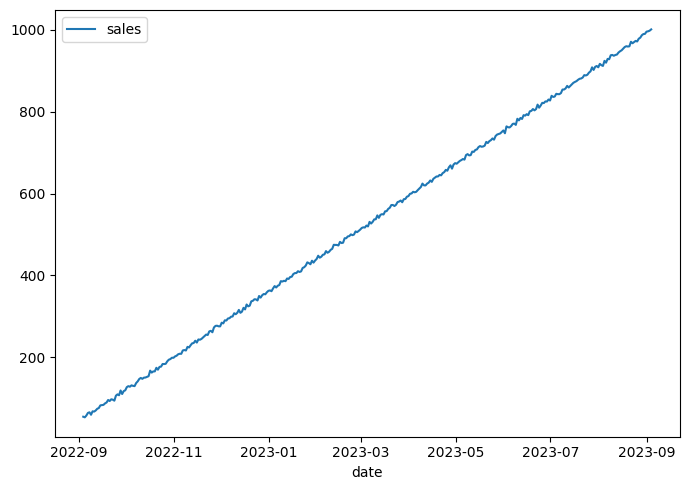

In [45]:
#Graficamos de manera rapida los datos
fig, axis = plt.subplots(figsize=(7,5))
sns.lineplot(data=df)
plt.tight_layout()
plt.show()

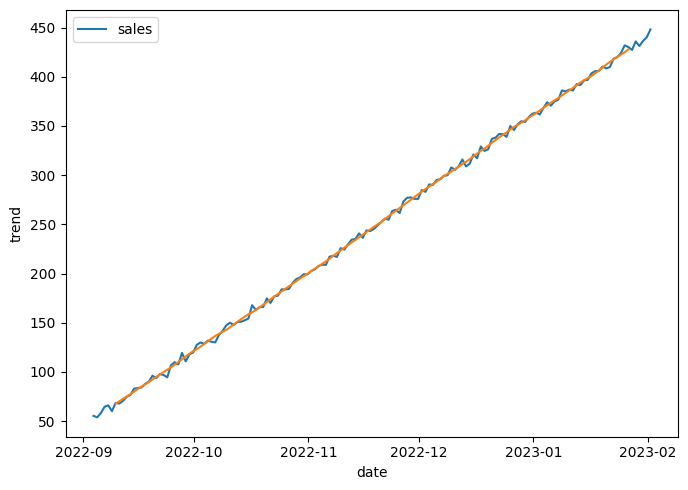

In [ ]:
# Vamos a  aplicar lo que vimos en clases y vamos a descomponer la serie de tiempo para extraer la tendencia y la estacionalidad
# Vamos a hacer un poco de "zoom" con "df.loc" para ver mejor la linea que atraviesa la serie de tiempo, es decir la tendencia
df_aux=df.loc['2022-09-01':'2023-02-01']
decomposition = seasonal_decompose(df,period=12)
decomposition_aux = seasonal_decompose(df_aux,period=12)
trend = decomposition_aux.trend
fig, axis = plt.subplots(figsize=(7,5))
sns.lineplot(data=df_aux)
sns.lineplot(data=trend)
plt.tight_layout()
plt.show()

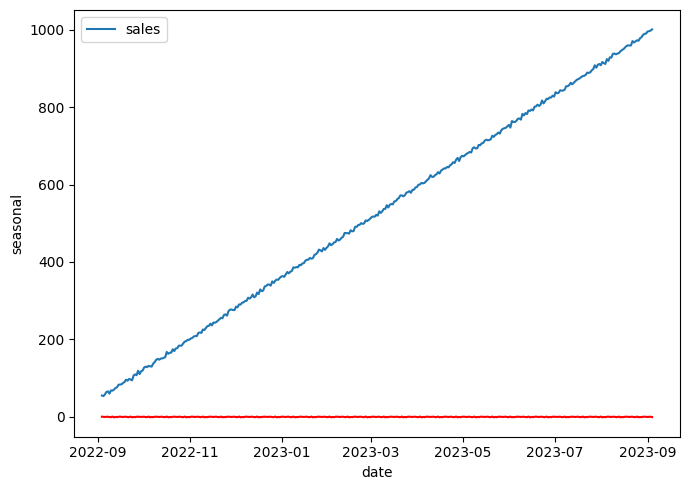

In [47]:
#Extraigo la estacionalidad de mi objeto descomposition ahora si "zoom"
seasonal = decomposition.seasonal
fig, axis = plt.subplots(figsize=(7,5))
sns.lineplot(data=df)
sns.lineplot(data=seasonal,color='red')
plt.tight_layout()
plt.show()

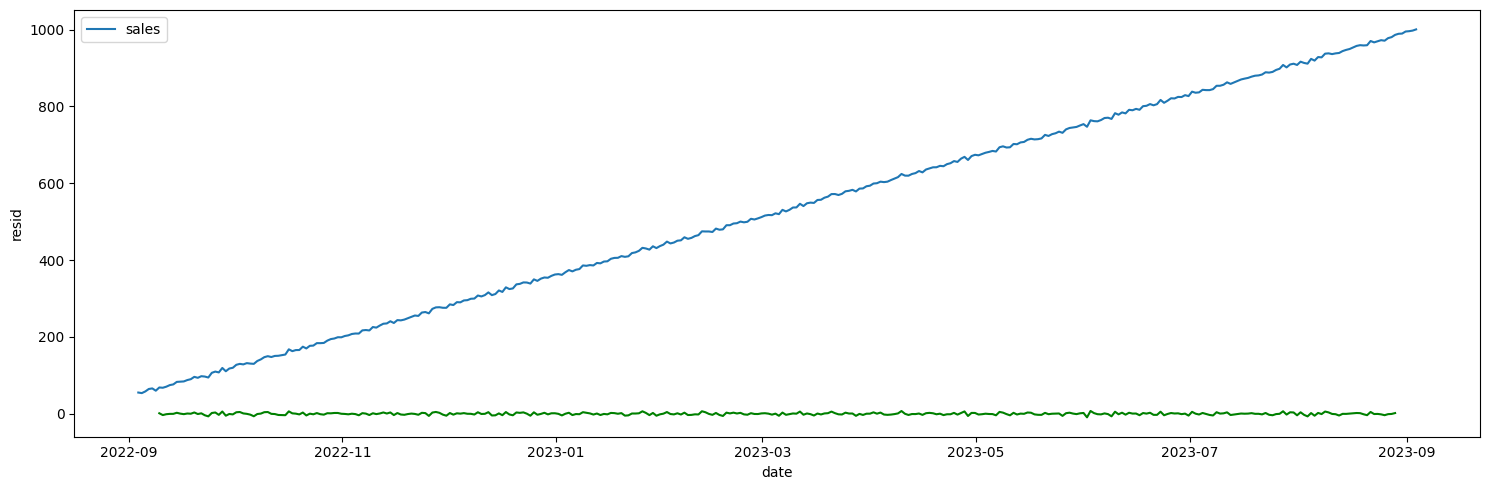

In [51]:
#No parece haber residual, pero vamos a graficarlo para ver que podemos encontrar
residual = decomposition.resid
fig, axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=df)
sns.lineplot(data=residual,color='green')
plt.tight_layout()
plt.show()

In [48]:
# En clases vimos como podemos hacer la prueba de Dickey-Fuller para saber si nuestra serie de tiempo es estacionaria o no, vamos a aplicarla a nuestro dataset
def test_stationarity(timeseries):
    print("Resultados de la Prueba Dickey-Fuller")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    return dfoutput

test_stationarity(df)

Resultados de la Prueba Dickey-Fuller


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

# Analisis hasta ahora:
* Tenemos un fataframe con 366 filas, y 2 columnas `date` y `sales` que van desde el 2022-09-03 al 2023-09-03.
* Los dates incluyen hora.
* los `sales` son float y no hay nulos.
* **Tendencia**: Hay una tendencia positiva a medida que pasa el tiempo, Esto puede deberse a que el plan de accion en ventas que ha tomado la empresa desde su creacion a funcionado con creces,y a medida que se han dado a conocer ahan vendido mas y por ende producir mas.
* **Estacionalidad** y **ruido**: No se observa estacionalidad o patrones de cambios visibles ni un ruido(por lo menos considerable) que nos lo indique, Tampoco la prueba de Dickey-Fuller nos arrojo un p-value para que lo consideremos, posiblemente nuestro producto no dependa de la estacion anque solo estamos evaluando un año esto podria cambiar.
* **Outliers**: Tampoco podemos observar outliers la grafica nos indica casi una linea acendente perfecta sin desviaciones.
* **Puntos De Inflexion**: Como indicamos antes la linea acendente es estable no se desvia ni para arriba ni para abajo, las ventas han estado muy controladas.

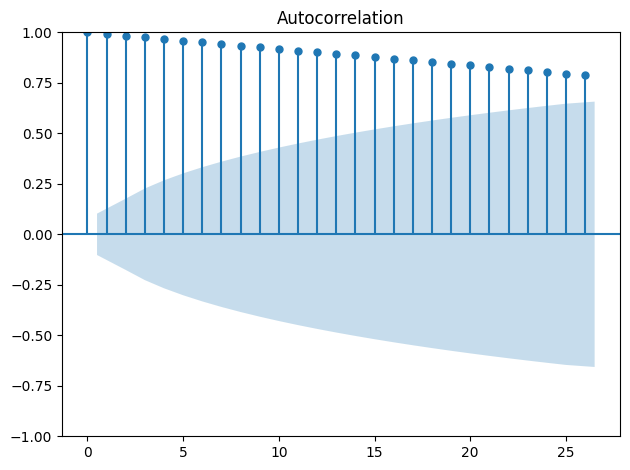